In [1]:
# Cell 1 — Load files
import pandas as pd
from pathlib import Path

MASTER_CSV = Path("data/vera_dataset_consensus_master.csv")
PRED_CSV   = Path("outputs/contested_predictions_all_labels_XGBoost.csv")

OUT_CSV    = Path("outputs/final_label.csv")
OUT_CSV.parent.mkdir(parents=True, exist_ok=True)

master = pd.read_csv(MASTER_CSV)
preds  = pd.read_csv(PRED_CSV)

print("Master shape:", master.shape)
print("Preds  shape:", preds.shape)
print("\nMaster columns:", list(master.columns))
print("Preds  columns:", list(preds.columns))


Master shape: (15448, 6)
Preds  shape: (2584, 2)

Master columns: ['SHA256', 'ClarAVy', 'AVClass', 'Euphony', 'Final_Family', 'Consensus_Type']
Preds  columns: ['SHA256', 'Predicted_Family']


In [2]:
# Cell 2 — Keep ONLY (majority_vote + strong_consensus_2 + strong_consensus_3) from master, and select SHA256 + Final_Family

# Robust column lookup
def find_col(df, names):
    cols = {c.strip().lower(): c for c in df.columns}
    for n in names:
        if n in cols:
            return cols[n]
    return None

sha_col_master = find_col(master, ["sha256", "sha"])
fam_col_master = find_col(master, ["final_family", "family"])
con_col_master = find_col(master, ["consensus_type", "consensus"])

if sha_col_master is None or fam_col_master is None or con_col_master is None:
    raise ValueError(
        f"Missing required columns in master.\n"
        f"Found: sha={sha_col_master}, family={fam_col_master}, consensus={con_col_master}\n"
        f"Columns: {list(master.columns)}"
    )

keep_types = {"majority_vote", "strong_consensus_3", "strong_consensus_2"}

master_filt = master.copy()
master_filt["_cons_lc"] = master_filt[con_col_master].astype(str).str.strip().str.lower()

master_keep = master_filt[master_filt["_cons_lc"].isin(keep_types)][[sha_col_master, fam_col_master]].copy()
master_keep.columns = ["SHA256", "Final_Family"]

# Normalize SHA formatting
master_keep["SHA256"] = master_keep["SHA256"].astype(str).str.strip().str.lower()
master_keep["Final_Family"] = master_keep["Final_Family"].astype(str).str.strip()

print("Kept from master:", master_keep.shape)
master_keep.head()


Kept from master: (12864, 2)


,SHA256,Final_Family
0,0003c4ac06a2ae23eff788a3ff179174f588fbf28e8766...,stop
2,000a0b2e04e49119a62a1ec860e88e97374864789f9b51...,pihun
3,000dca0ac54c86a00cadcbec0af08128508603bc303049...,gimemo
4,00131a827e218ca3505cd5e3cf5201889d6930b0c8bbcf...,fullscreen
5,00133805d692da064e8e47b1d06298998764c5284606bb...,xorist


In [3]:
# Cell 3 — Standardize predictions file to the same columns (SHA256, Final_Family)

sha_col_pred = find_col(preds, ["sha256", "sha"])
fam_col_pred = find_col(preds, ["final_family", "predicted_family", "family", "label", "prediction"])

if sha_col_pred is None:
    raise ValueError(f"Couldn't find SHA column in predictions. Columns: {list(preds.columns)}")

# If family column isn't detected, assume it's the other column (since you said it's only sha + family)
if fam_col_pred is None:
    non_sha = [c for c in preds.columns if c != sha_col_pred]
    if len(non_sha) == 1:
        fam_col_pred = non_sha[0]
    else:
        raise ValueError(f"Couldn't find family column in predictions. Columns: {list(preds.columns)}")

pred_keep = preds[[sha_col_pred, fam_col_pred]].copy()
pred_keep.columns = ["SHA256", "Final_Family"]

pred_keep["SHA256"] = pred_keep["SHA256"].astype(str).str.strip().str.lower()
pred_keep["Final_Family"] = pred_keep["Final_Family"].astype(str).str.strip()

print("Kept from predictions:", pred_keep.shape)
pred_keep.head()


Kept from predictions: (2584, 2)


,SHA256,Final_Family
0,0007eb3ccafe69715a2184404083637512e9c93b1b4494...,gimemo
1,00295b2860973dd70e99e3ae0fea043c20aff3970038a6...,weenloc
2,0033c6e1db4b59f95b5261ecef244981e068c765f32616...,shade
3,0034a32c194bf42aee4faa73b028c4138874cc79c4a1ed...,gimemo
4,004cdc6996225f244aef124edc72f90434a872b3d4fa56...,globeimposter


In [4]:
# Cell 4 — Merge (stack) both sets, drop duplicates by SHA, and save final_label.csv

combined = pd.concat([master_keep, pred_keep], ignore_index=True)

# If any SHA appears in both, prefer the master label by keeping first occurrence (master_keep is first)
before = len(combined)
combined = combined.drop_duplicates(subset=["SHA256"], keep="first").reset_index(drop=True)
after = len(combined)

print(f"Combined rows before dedup: {before}")
print(f"Combined rows after  dedup: {after}")
print(f"Duplicates removed: {before - after}")

combined.to_csv(OUT_CSV, index=False)
print("Saved:", OUT_CSV)

combined.head()


Combined rows before dedup: 15448
Combined rows after  dedup: 15448
Duplicates removed: 0
Saved: outputs/final_label.csv


,SHA256,Final_Family
0,0003c4ac06a2ae23eff788a3ff179174f588fbf28e8766...,stop
1,000a0b2e04e49119a62a1ec860e88e97374864789f9b51...,pihun
2,000dca0ac54c86a00cadcbec0af08128508603bc303049...,gimemo
3,00131a827e218ca3505cd5e3cf5201889d6930b0c8bbcf...,fullscreen
4,00133805d692da064e8e47b1d06298998764c5284606bb...,xorist


In [5]:
# Cell 1 — Load final labels
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

FINAL_CSV = Path("outputs/final_label.csv")  # <- change if needed
df = pd.read_csv(FINAL_CSV)

# basic sanity
df["SHA256"] = df["SHA256"].astype(str).str.strip().str.lower()
df["Final_Family"] = df["Final_Family"].astype(str).str.strip()

print("Rows:", len(df))
print("Unique SHA:", df["SHA256"].nunique())
print("Unique families:", df["Final_Family"].nunique())
df.head()


Rows: 15448
Unique SHA: 15448
Unique families: 631


,SHA256,Final_Family
0,0003c4ac06a2ae23eff788a3ff179174f588fbf28e8766...,stop
1,000a0b2e04e49119a62a1ec860e88e97374864789f9b51...,pihun
2,000dca0ac54c86a00cadcbec0af08128508603bc303049...,gimemo
3,00131a827e218ca3505cd5e3cf5201889d6930b0c8bbcf...,fullscreen
4,00133805d692da064e8e47b1d06298998764c5284606bb...,xorist


In [7]:
# Cell 2 — Family counts table (top 20) + save full counts CSV
counts = df["Final_Family"].value_counts().rename_axis("Final_Family").reset_index(name="Count")
counts["Percent"] = (counts["Count"] / counts["Count"].sum() * 100).round(2)

display(counts.head(20))

out_counts = Path("outputs/family_counts.csv")
out_counts.parent.mkdir(parents=True, exist_ok=True)
counts.to_csv(out_counts, index=False)
print("Saved:", out_counts)


,Final_Family,Count,Percent
0,gimemo,1605,10.39
1,timer,808,5.23
2,revil,650,4.21
3,fullscreen,629,4.07
4,locky,610,3.95
5,cerber,585,3.79
6,zedopoo,571,3.70
7,pornoasset,528,3.42
8,fakeinstaller,498,3.22
9,xorist,453,2.93


Saved: outputs/family_counts.csv


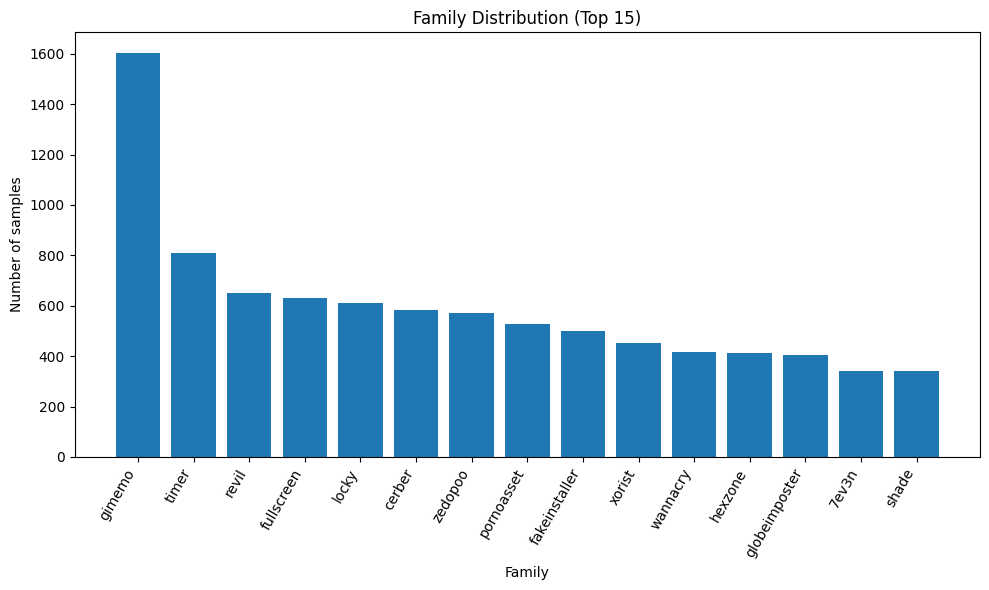

Saved: outputs/Fig_family_distribution_top15.png and outputs/Fig_family_distribution_top15.pdf


In [8]:
# Cell 3 — Plot: Top-15 families bar chart (PNG + PDF)
top_k = 15
top = counts.head(top_k).copy()

fig_path_png = Path("outputs/Fig_family_distribution_top15.png")
fig_path_pdf = Path("outputs/Fig_family_distribution_top15.pdf")

plt.figure(figsize=(10, 6))
plt.bar(top["Final_Family"], top["Count"])
plt.xticks(rotation=60, ha="right")
plt.title(f"Family Distribution (Top {top_k})")
plt.xlabel("Family")
plt.ylabel("Number of samples")
plt.tight_layout()
plt.savefig(fig_path_png, dpi=300, bbox_inches="tight")
plt.savefig(fig_path_pdf, bbox_inches="tight")
plt.show()

print("Saved:", fig_path_png, "and", fig_path_pdf)


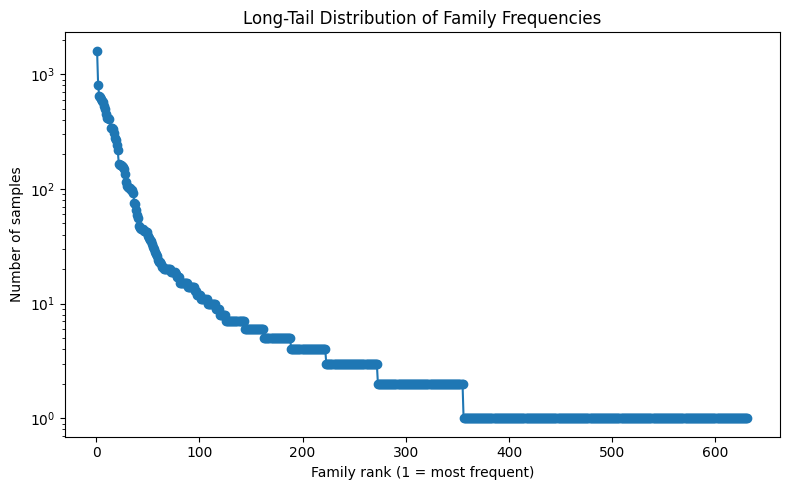

Saved: outputs/Fig_longtail_rank_count.png and outputs/Fig_longtail_rank_count.pdf


In [9]:
# # Cell 4 — Plot: Long-tail (rank vs count) to show imbalance (PNG + PDF)
# rank_counts = counts["Count"].values
# ranks = np.arange(1, len(rank_counts) + 1)

# fig_path_png = Path("outputs/Fig_longtail_rank_count.png")
# fig_path_pdf = Path("outputs/Fig_longtail_rank_count.pdf")

# plt.figure(figsize=(8, 5))
# plt.plot(ranks, rank_counts, marker="o", linestyle="-")
# plt.title("Long-Tail Distribution of Family Frequencies")
# plt.xlabel("Family rank (1 = most frequent)")
# plt.ylabel("Number of samples")
# plt.yscale("log")   # log scale makes the long tail clear
# plt.tight_layout()
# plt.savefig(fig_path_png, dpi=300, bbox_inches="tight")
# plt.savefig(fig_path_pdf, bbox_inches="tight")
# plt.show()

# print("Saved:", fig_path_png, "and", fig_path_pdf)


In [10]:
# # Cell 5 — Table: Coverage by threshold (e.g., families with >=50 samples)
# thresholds = [10, 20, 50, 100]

# summary = []
# total = len(df)
# for t in thresholds:
#     fam_ge_t = (counts["Count"] >= t).sum()
#     samples_ge_t = counts.loc[counts["Count"] >= t, "Count"].sum()
#     summary.append({
#         "Min samples per family": t,
#         "Families meeting threshold": int(fam_ge_t),
#         "Samples covered": int(samples_ge_t),
#         "Coverage %": round(samples_ge_t / total * 100, 2)
#     })

# summary_df = pd.DataFrame(summary)
# display(summary_df)

# out_summary = Path("outputs/family_threshold_coverage.csv")
# summary_df.to_csv(out_summary, index=False)
# print("Saved:", out_summary)


,Min samples per family,Families meeting threshold,Samples covered,Coverage %
0,10,115,14266,92.35
1,20,72,13683,88.57
2,50,41,12733,82.42
3,100,33,12114,78.42


Saved: outputs/family_threshold_coverage.csv
